# Utilisation 

## Initialiser un projet

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   # car notebook est dans notebook/ et pas dans le root du projet
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from cartograpy.project import *

# Initialiser un projet avec un CRS et des dossiers par défaut
projet = Project(
    path="./mon_projet/",   # répertoire racine du projet
    data_dir="data",        # dossier des données
    output_dir="output",    # dossier des résultats
    crs="EPSG:4326"         # système de coordonnées (WGS 84)
)
projet.init()

✅ Projet initialisé dans : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet
   📁 c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data
   📁 c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\output


C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


'c:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet'

## Lire et écrire des données vectorielles

In [ ]:
from cartograpy.data import *

In [ ]:
# Lire un fichier vectoriel (GeoJSON, Shapefile, GeoPackage, etc.)
vecteur = load("../data/vector/gadm41_CIV.gpkg")
vecteur.head()

In [ ]:
# Lire un fichier GPX (traces GPS)
gpx_track = load("../data/vector/données tracées.gpx")
gpx_track.head()

In [ ]:
# Lire un fichier GPX (traces GPS)
gpx_waypoints = load("../data/vector/données tracées.gpx", layer="waypoints")  # spécifier la couche "waypoints" pour les points d'intérêt
gpx_waypoints.head()

In [ ]:
# Lire un fichier raster (GeoTIFF)
raster = load("../data/raster/DEM.tif")
print("CRS :", raster.crs)
print("Dimensions :", raster.width, "x", raster.height)
print("Emprise :", raster.bounds)
raster.close()

## Sauvegarder des données dans le projet

In [ ]:
projet.add_data(gpx_track, "geojson", filename="données_tracées_track",overwrite=True)

In [ ]:
projet.add_data(raster, "tif", filename="données_raster", raster_meta=True, overwrite=True)

In [ ]:
save (vecteur, "geojson", "./mon_projet/data/limite_ci")

## Carte de situation de Yamoussoukro

In [ ]:
from cartograpy.data import Bound

# Télécharger les frontières des pays d'Afrique de l'Ouest (ADM0)
bound = Bound()
civ = bound.get_admin("Côte d'Ivoire", adm=0)       # Côte d'Ivoire
afrique_ouest = bound.get_admin(
    ["Côte d'Ivoire", "Ghana", "Burkina Faso", "Mali", "Guinée",
     "Liberia", "Sierra Leone", "Sénégal", "Togo", "Bénin", "Niger", "Nigeria"],
    adm=0
)
afrique_ouest.head()

In [ ]:
afrique_ouest.plot()

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pypalettes import load_cmap
from drawarrow import fig_arrow
from pyfonts import load_google_font
from highlight_text import fig_text, ax_text


# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

world_url = (
    "https://raw.githubusercontent.com/holtzy/"
    "the-python-graph-gallery/master/static/data/europe.geojson"
)

co2_url = (
    "https://raw.githubusercontent.com/holtzy/"
    "the-python-graph-gallery/master/static/data/co2PerCapita.csv"
)

world = gpd.read_file(world_url)

df = pd.read_csv(co2_url)


# ============================================================
# 2. PRÉPARATION DES DONNÉES
# ============================================================

# S'assurer que Year est numérique
df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

# S'assurer que Total est numérique
df["Total"] = pd.to_numeric(
    df["Total"],
    errors="coerce"
)

# Fusion des données
data = world.merge(
    df,
    how="left",
    left_on="name",
    right_on="Country"
)

# Garder uniquement l'Europe
data = data[
    data["continent"] == "Europe"
].copy()

# Exclure la Russie et l'Islande
data = data[
    ~data["name"].isin(
        ["Russia", "Iceland"]
    )
].copy()

# Garder 2021
data = data[
    data["Year"] == 2021
].copy()

# Garder uniquement les colonnes utiles
data = data[
    ["name", "Total", "geometry"]
].copy()

# Supprimer les données manquantes
data = data.dropna(
    subset=["Total", "geometry"]
).copy()

print(data.head())
print(f"\nNombre de pays : {len(data)}")


# ============================================================
# 3. CARTE SIMPLE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

data.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

ax.set_xlim(-11, 41)
ax.set_ylim(32, 73)
ax.set_axis_off()

plt.show()


# ============================================================
# 4. CARTE CHOROPLÈTHE
# ============================================================

cmap = load_cmap(
    "BrwnYl",
    cmap_type="continuous"
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

data.plot(
    ax=ax,
    column="Total",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.5
)

ax.set_xlim(-11, 41)
ax.set_ylim(32, 73)
ax.set_axis_off()

plt.show()


# ============================================================
# 5. PARAMÈTRES GRAPHIQUES
# ============================================================

background_color = "white"
text_color = "black"

# Polices
font = load_google_font(
    "Bebas Neue"
)

other_font = load_google_font(
    "Fira Sans",
    weight="light"
)

other_bold_font = load_google_font(
    "Fira Sans",
    weight="medium"
)

# Propriétés des flèches
arrow_props = dict(
    width=0.5,
    head_width=4,
    head_length=8,
    color="black"
)


# ============================================================
# 6. AJUSTEMENTS DES ÉTIQUETTES
# ============================================================

adjustments = {
    "France": (10, 3),
    "Italy": (-2.4, 2.5),
    "Finland": (0, -2),
    "Belarus": (0, -0.4),
    "Ireland": (0, -1),
    "Germany": (-0.2, 0),
    "Poland": (0, 0.2),
    "Sweden": (-1.2, -2.8),
    "United Kingdom": (1, -1.5),
    "Norway": (-4, -5.5),
}


# ============================================================
# 7. CALCUL DES CENTROÏDES
# ============================================================

# Projection métrique adaptée à l'Europe
data_projected = data.to_crs(
    epsg=3035
)

data_projected["centroid"] = (
    data_projected
    .geometry
    .centroid
)

# Retour dans le CRS original
data["centroid"] = (
    data_projected["centroid"]
    .to_crs(data.crs)
)


# ============================================================
# 8. PAYS À ANNOTER
# ============================================================

countries_to_annotate = [
    "France",
    "Italy",
    "Romania",
    "Poland",
    "Finland",
    "Ukraine",
    "Spain",
    "Germany",
    "Sweden",
    "United Kingdom",
    "Belarus",
    "Norway",
]


# ============================================================
# 9. CARTE AVEC ANNOTATIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

fig.set_facecolor(
    background_color
)

ax.set_facecolor(
    background_color
)

# Carte
data.plot(
    ax=ax,
    column="Total",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.5
)

# Emprise
ax.set_xlim(-11, 41)
ax.set_ylim(32, 73)
ax.set_axis_off()


# ------------------------------------------------------------
# Annotations
# ------------------------------------------------------------

for country in countries_to_annotate:

    country_data = data[
        data["name"] == country
    ]

    # Éviter une erreur si le pays n'existe pas
    if country_data.empty:
        print(
            f"⚠ Pays absent : {country}"
        )
        continue

    centroid = country_data.iloc[0]["centroid"]

    x, y = centroid.coords[0]

    # Ajustement manuel
    dx, dy = adjustments.get(
        country,
        (0, 0)
    )

    x += dx
    y += dy

    # Valeur
    rate = country_data.iloc[0]["Total"]

    # Nom affiché
    display_country = (
        "UK"
        if country == "United Kingdom"
        else country
    )

    # Couleur du texte
    color_text = (
        "white"
        if rate > 7
        else text_color
    )

    ax_text(
        x=x,
        y=y,
        s=f"<{display_country.upper()}>: {rate:.2f}",
        fontsize=9,
        font=other_font,
        color=color_text,
        ha="center",
        va="center",
        ax=ax,
        highlight_textprops=[
            {
                "font": other_bold_font
            }
        ],
    )


# ============================================================
# 10. TITRE
# ============================================================

fig_text(
    s="CO2 emissions per capita in Europe (2021)",
    x=0.5,
    y=0.14,
    color=text_color,
    fontsize=25,
    font=font,
    ha="center",
    va="top",
    fig=fig,
)


# ============================================================
# 11. SOUS-TITRE
# ============================================================

fig_text(
    s="<Unit>: metric tons | <Data>: zenodo.org | <Viz>: barbierjoseph.com",
    x=0.5,
    y=0.10,
    color=text_color,
    fontsize=14,
    font=other_font,
    ha="center",
    va="top",
    fig=fig,
    highlight_textprops=[
        {"font": other_bold_font},
        {"font": other_bold_font},
        {"font": other_bold_font},
    ],
)


# ============================================================
# 12. LUXEMBOURG
# ============================================================

luxembourg = data[
    data["name"] == "Luxembourg"
]

if not luxembourg.empty:

    luxembourg_value = (
        luxembourg.iloc[0]["Total"]
    )

    fig_arrow(
        tail_position=(0.32, 0.70),
        head_position=(0.375, 0.45),
        radius=0.3,
        **arrow_props
    )

    fig_text(
        s=f"<LUXEMBOURG>: {luxembourg_value:.2f}",
        x=0.32,
        y=0.71,
        highlight_textprops=[
            {
                "font": other_bold_font
            }
        ],
        color=text_color,
        fontsize=9,
        font=other_font,
        ha="center",
        va="center",
        fig=fig,
    )


plt.show()


# ============================================================
# 13. CARTE FINALE AVEC LÉGENDE
# ============================================================

value_ranges = [
    0,
    2,
    4,
    6,
    8,
    10,
    12,
    15
]

labels = [
    "0-2 t",
    "2-4 t",
    "4-6 t",
    "6-8 t",
    "8-10 t",
    "10-12 t",
    "12+ t"
]


# ============================================================
# 14. FIGURE FINALE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

fig.set_facecolor(
    background_color
)

ax.set_facecolor(
    background_color
)


# ------------------------------------------------------------
# Carte
# ------------------------------------------------------------

data.plot(
    ax=ax,
    column="Total",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.5
)

ax.set_xlim(-11, 41)
ax.set_ylim(32, 73)
ax.set_axis_off()


# ============================================================
# 15. LÉGENDE
# ============================================================

rectangle_width = 2
rectangle_height = 1.5

legend_x = 35
legend_y_start = 65
legend_y_step = 1.5


for i, label in enumerate(labels):

    # Valeur représentative de la classe
    value = (
        (value_ranges[i] + value_ranges[i + 1])
        / 2
        / value_ranges[-1]
    )

    color = cmap(value)

    ax.add_patch(
        plt.Rectangle(
            (
                legend_x,
                legend_y_start
                - i * legend_y_step
            ),
            rectangle_width,
            rectangle_height,
            color=color,
            ec="black",
            lw=0.6
        )
    )

    ax.text(
        legend_x + 2.5,
        legend_y_start
        - i * legend_y_step
        + 0.7,
        label,
        fontsize=12,
        fontproperties=other_font,
        color=text_color,
        va="center"
    )


# ============================================================
# 16. ANNOTATIONS
# ============================================================

for country in countries_to_annotate:

    country_data = data[
        data["name"] == country
    ]

    if country_data.empty:
        continue

    centroid = (
        country_data.iloc[0]["centroid"]
    )

    x, y = centroid.coords[0]

    dx, dy = adjustments.get(
        country,
        (0, 0)
    )

    x += dx
    y += dy

    rate = country_data.iloc[0]["Total"]

    display_country = (
        "UK"
        if country == "United Kingdom"
        else country
    )

    color_text = (
        "white"
        if rate > 7
        else text_color
    )

    ax_text(
        x=x,
        y=y,
        s=f"<{display_country.upper()}>: {rate:.2f}",
        fontsize=9,
        font=other_font,
        color=color_text,
        ha="center",
        va="center",
        ax=ax,
        highlight_textprops=[
            {
                "font": other_bold_font
            }
        ],
    )


# ============================================================
# 17. TITRE
# ============================================================

fig_text(
    s="CO2 emissions per capita in Europe (2021)",
    x=0.5,
    y=0.14,
    color=text_color,
    fontsize=25,
    font=font,
    ha="center",
    va="top",
    fig=fig,
)


# ============================================================
# 18. SOUS-TITRE
# ============================================================

fig_text(
    s="<Unit>: metric tons | <Data>: zenodo.org | <Viz>: barbierjoseph.com",
    x=0.5,
    y=0.10,
    color=text_color,
    fontsize=14,
    font=other_font,
    ha="center",
    va="top",
    fig=fig,
    highlight_textprops=[
        {"font": other_bold_font},
        {"font": other_bold_font},
        {"font": other_bold_font},
    ],
)


# ============================================================
# 19. FLÈCHE LUXEMBOURG
# ============================================================

luxembourg = data[
    data["name"] == "Luxembourg"
]

if not luxembourg.empty:

    luxembourg_value = (
        luxembourg.iloc[0]["Total"]
    )

    fig_arrow(
        tail_position=(0.32, 0.70),
        head_position=(0.375, 0.45),
        radius=0.3,
        **arrow_props
    )

    fig_text(
        s=f"<LUXEMBOURG>: {luxembourg_value:.2f}",
        x=0.32,
        y=0.71,
        highlight_textprops=[
            {
                "font": other_bold_font
            }
        ],
        color=text_color,
        fontsize=9,
        font=other_font,
        ha="center",
        va="center",
        fig=fig,
    )


# ============================================================
# 20. EXPORT
# ============================================================

output_dir = "../../static/graph"

os.makedirs(
    output_dir,
    exist_ok=True
)

output_file = os.path.join(
    output_dir,
    "web-map-with-custom-legend.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

print(
    f"Carte enregistrée : {output_file}"
)

plt.show()

# CARTOGRAPY

📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.20
   Étendue: [-61.15, 46.70, -12.57, 95.28]
🖼️ Image ajoutée
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.27
   Étendue: [-14.64, 44.64, 22.86, 82.14]
Carte sauvegardée: web-map-with-custom-legend.png


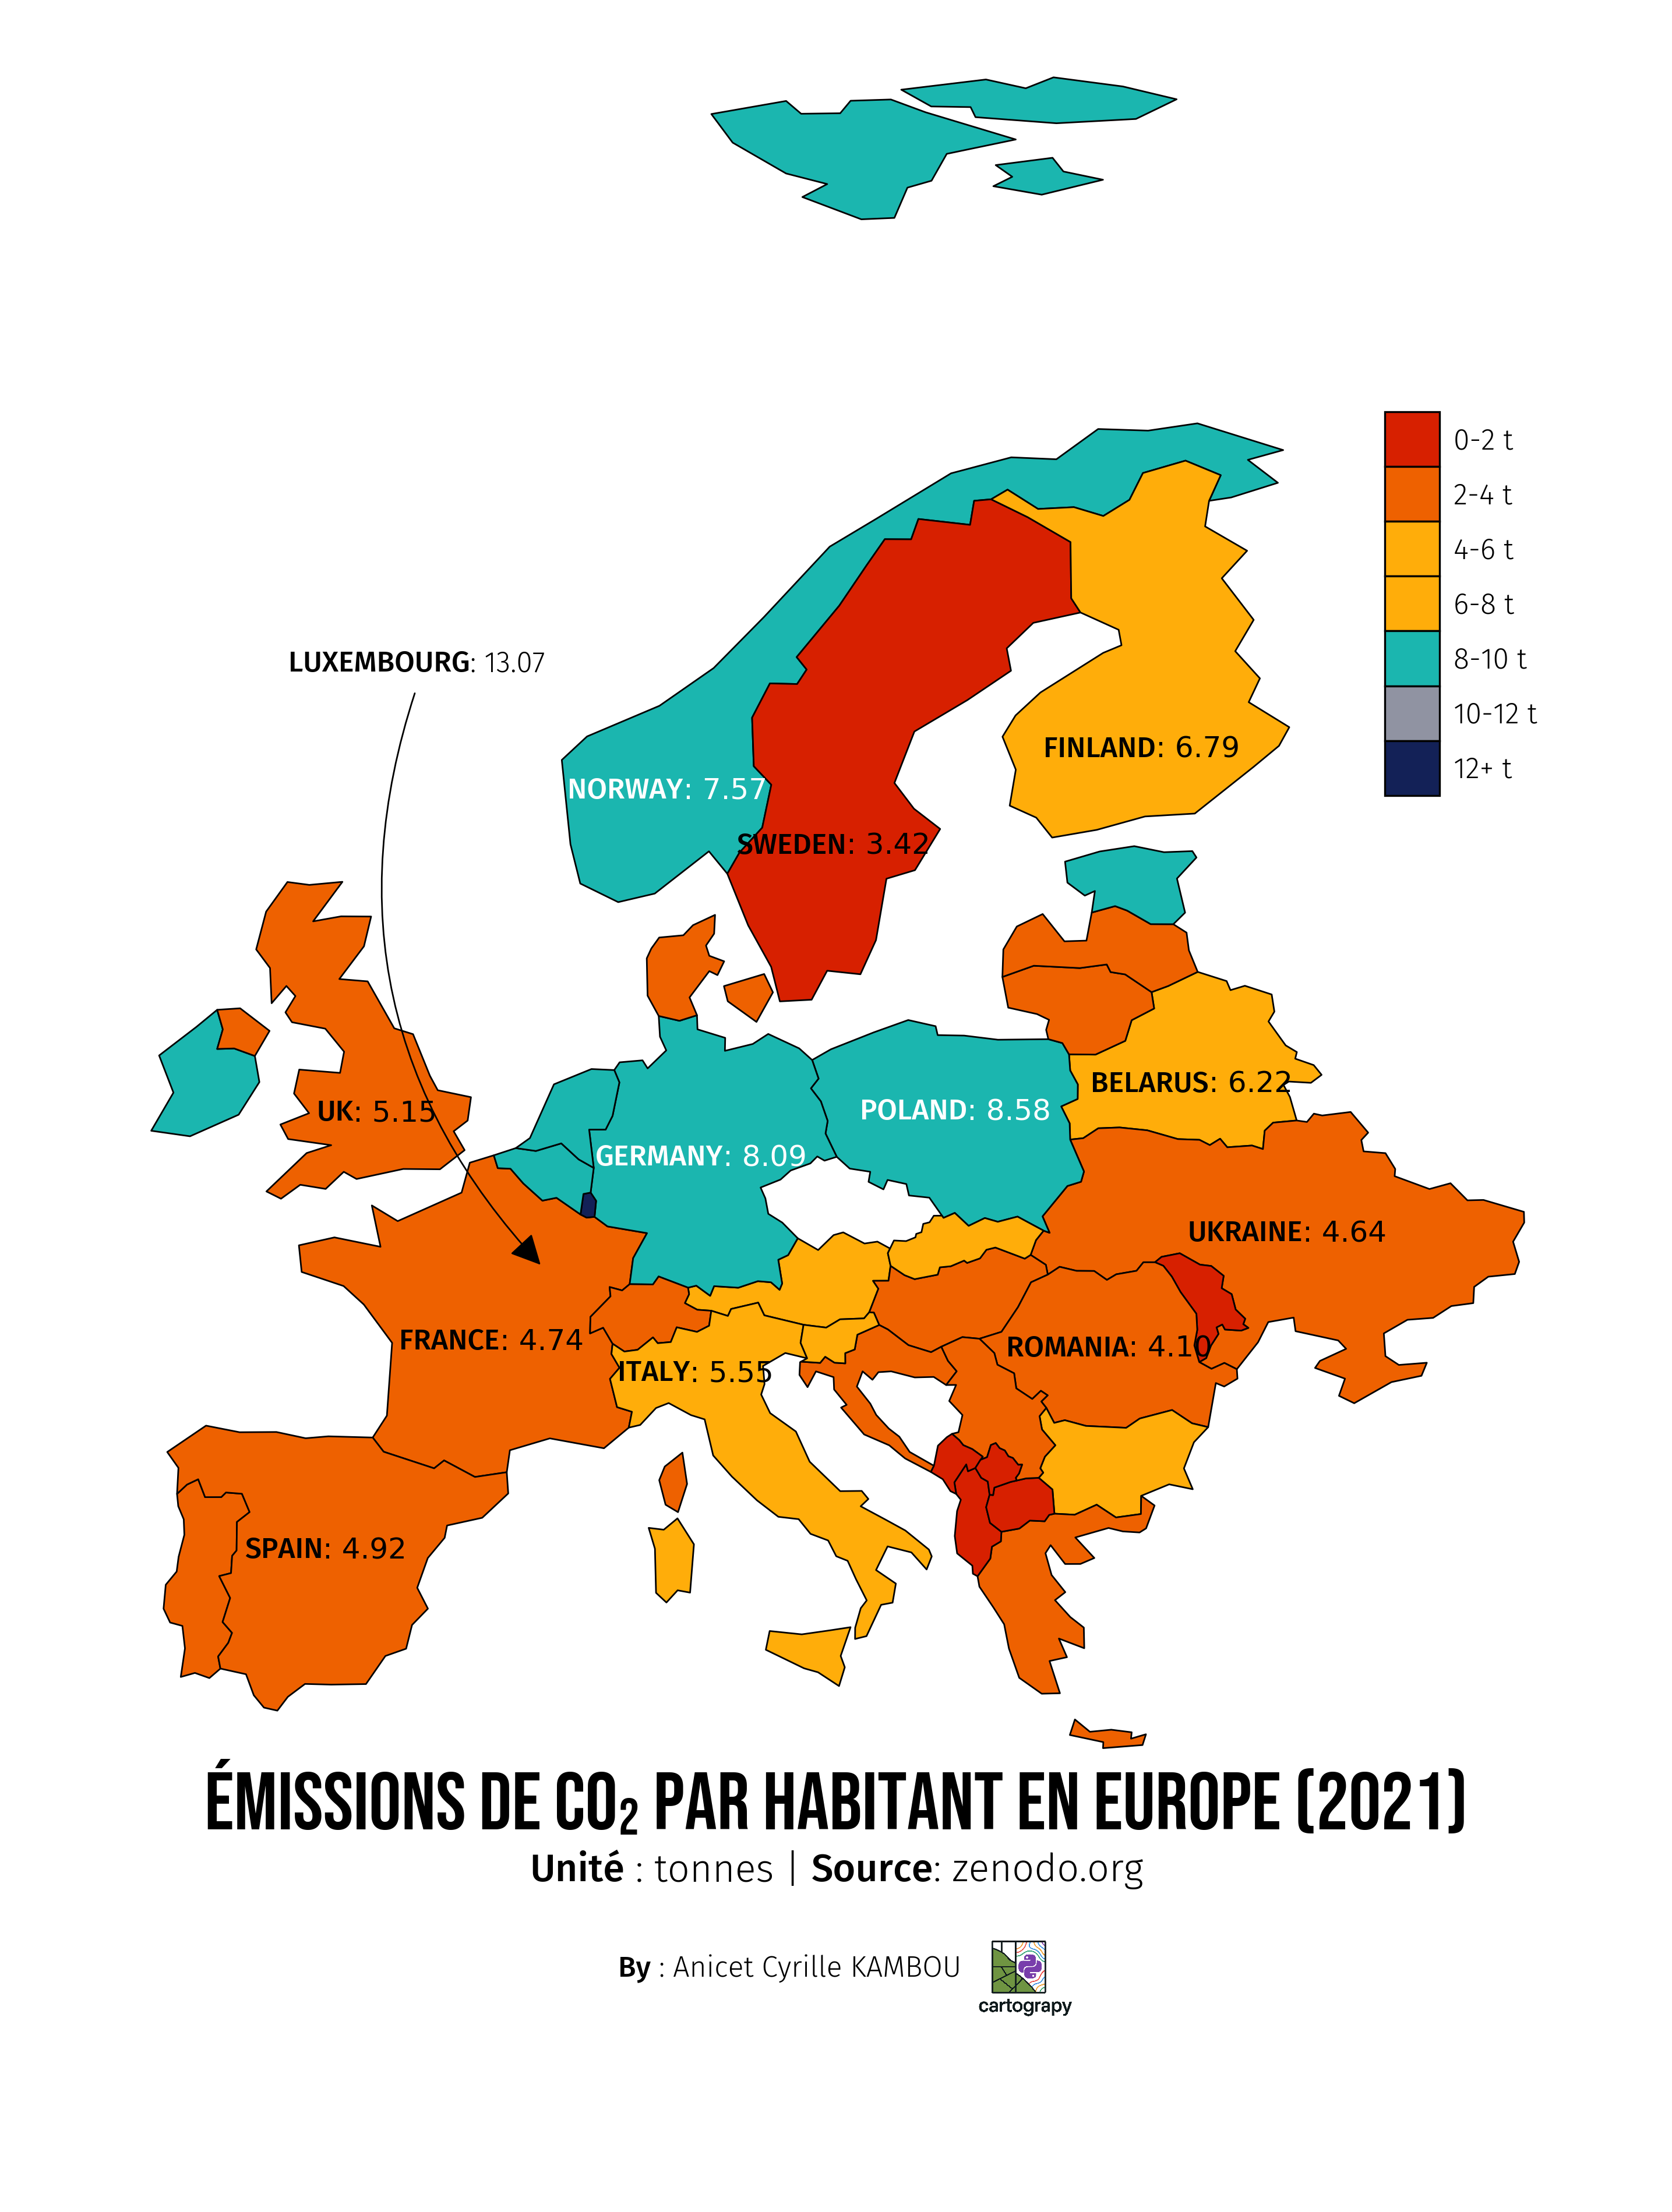

In [ ]:
import pandas as pd
import cartograpy as cp

# 1. DONNÉES
world = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/europe.geojson"
)
df = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/co2PerCapita.csv"
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

## Fusion des données
data = world.merge(df, how="left", left_on="name", right_on="Country")

## Filtrage des données pour l'Europe, en excluant la Russie et l'Islande, et en ne gardant que l'année 2021
data = data.query('continent == "Europe" and name not in ["Russia", "Iceland"] and Year == 2021')
data = data[["name", "Total", "geometry"]].dropna(subset=["Total", "geometry"]).copy()

proj = data.to_crs(epsg=3035)
data["centroid"] = proj.geometry.centroid.to_crs(data.crs)

# 2. POLICES
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")

text_color = "black"
background_color = "white"

# 3. CARTE
m = cp.Map(figsize=(10, 10), dpi=400, basemap=False, title="")
m.set_background_color(background_color)
m.add_polygons_choropleth(
    data,
    column_to_plot="Total",
    cmap="Apricot",
    edge_color="black",
    linewidth=0.5,
    show_labels=True,
    show_colorbar=False,
)
m.set_extent([-11, 32, 41, 73])
m.hide_gridline()
# m.add_basemap()

# 4. ANNOTATIONS PAR PAYS (nom en gras inline via add_custom_text)
adjustments = {
    "France": (10, 3), "Italy": (-2.4, 2.5), "Finland": (0, -2),
    "Belarus": (0, -0.4), "Ireland": (0, -1), "Germany": (-0.2, 0),
    "Poland": (0, 0.2), "Sweden": (-1.2, -2.8),
    "United Kingdom": (1, -1.5), "Norway": (-4, -5.5),
}
countries_to_annotate = [
    "France", "Italy", "Romania", "Poland", "Finland", "Ukraine",
    "Spain", "Germany", "Sweden", "United Kingdom", "Belarus", "Norway",
]

data_by_country = data.set_index("name")

for country in countries_to_annotate:
    if country not in data_by_country.index:
        continue
    row = data_by_country.loc[country]
    dx, dy = adjustments.get(country, (0, 0))
    x, y = row["centroid"].x + dx, row["centroid"].y + dy
    rate = row["Total"]
    label = "UK" if country == "United Kingdom" else country

    m.add_custom_text(
        f"<{label.upper()}>: {rate:.2f}", (x, y), to="ax",
        fontsize=9, color="white" if rate > 7 else text_color,
        ha="center", va="center",
        highlight_textprops=[{"font": font_bold}],
    )


# 5. LUXEMBOURG (add_fig_arrow + add_custom_text, en coords figure 0-1)
lux = data[data["name"] == "Luxembourg"]
if not lux.empty:
    lux_value = lux.iloc[0]["Total"]

    m.add_fig_arrow(
        tail_position=(0.32, 0.70),
        head_position=(0.375, 0.45),
        radius=0.3,
        width=0.5, head_width=4, head_length=8, color="black",
    )
    m.add_custom_text(
        f"<LUXEMBOURG>: {lux_value:.2f}", (0.32, 0.71), to="fig",
        highlight_textprops=[{"font": font_bold}],
        color=text_color, fontsize=9, font=font_text,
        ha="center", va="center",
    )

# 6. LÉGENDE PAR CLASSES
value_ranges = [0, 2, 4, 6, 8, 10, 12, 15]
labels = ["0-2 t", "2-4 t", "4-6 t", "6-8 t", "8-10 t", "10-12 t", "12+ t"]
cmap_obj = cp.load_cmap("Apricot")

items = [
    (lab, cmap_obj((value_ranges[i] + value_ranges[i + 1]) / 2 / value_ranges[-1]))
    for i, lab in enumerate(labels)
]
m.add_swatch_legend(
    items, xy=(35, 70),
    rect_width=2, 
    rect_height=1.5, y_step=1.5,
    fontsize=9, color=text_color,
    edge_color="black", linewidth=0.6,
    font=font_text,
)

# 7. TITRE / SOUS-TITRE
m.add_custom_text(
    "Émissions de CO₂ par habitant en Europe (2021)", (0.5, 0.8), to="fig",
    color=text_color, fontsize=25, font=font_title,
    ha="center", va="top",
)
m.add_custom_text(
    "<Unité> : tonnes | <Source>: zenodo.org", (0.5, 0.2), to="fig",
    color=text_color, fontsize=12, font=font_text,
    ha="center", va="top",
    highlight_textprops=[{"font": font_bold}, {"font": font_bold}],
)

m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.48, 0.15), to="fig",
    color=text_color, fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

# m.add_north_arrow(to="fig", shadow=False,scale=0.3, label=" ",position=(0.3, 0.85))

m.add_image("logo.png", (0.44, 0.1), zoom=0.035) 

# m.add_background_image("bg_image.jpg", alpha=0.5, zoom=1)
# 8. EXPORT
m.save("web-map-with-custom-legend.png", dpi=600)
# data.head()

In [ ]:
from cartograpy.styling import *
from cartograpy.mapper import *
from cartograpy.data import *
from cartograpy.processing import *

In [ ]:
belier = bound.get_admin("CIV", adm=2).query("shapeName == 'Belier'")
belier.head()

In [ ]:
civ=bound.get_admin("CIV", adm=0)
civ.head()

## Carte interactive (WebMap)

## Traitement des données vectorielles

In [ ]:
from cartograpy.processing import centroids, fusion, join, add_column

# Calculer les centroïdes des régions
centres = centroids(vecteur)
centres.head()

In [ ]:
# Jointure spatiale : associer les waypoints GPS aux régions
resultat_jointure = join(
    (gpx_waypoints, "points GPS"),
    (vecteur, "régions"),
)
resultat_jointure.head()

## Téléchargement de données géographiques

In [ ]:
from cartograpy.data import Bound, OSM

# Télécharger les limites d'un pays via GeoBoundaries
bound = Bound()
civ = bound.get_country("Côte d'Ivoire")
civ.head()

In [ ]:
# Télécharger des données OSM (écoles de Yamoussoukro)
osm = OSM()
ecoles = osm.get_data("Yamoussoukro, Côte d'Ivoire", tags={"amenity": "school"}, data_type="points")
ecoles.head()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
🧭 Flèche du Nord ajoutée (map-utils)


C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:975: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  return self._add_gdf_layer(


📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.50
   Ratio données: 0.95
   Étendue: [-11.00, -0.08, 3.91, 11.19]


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


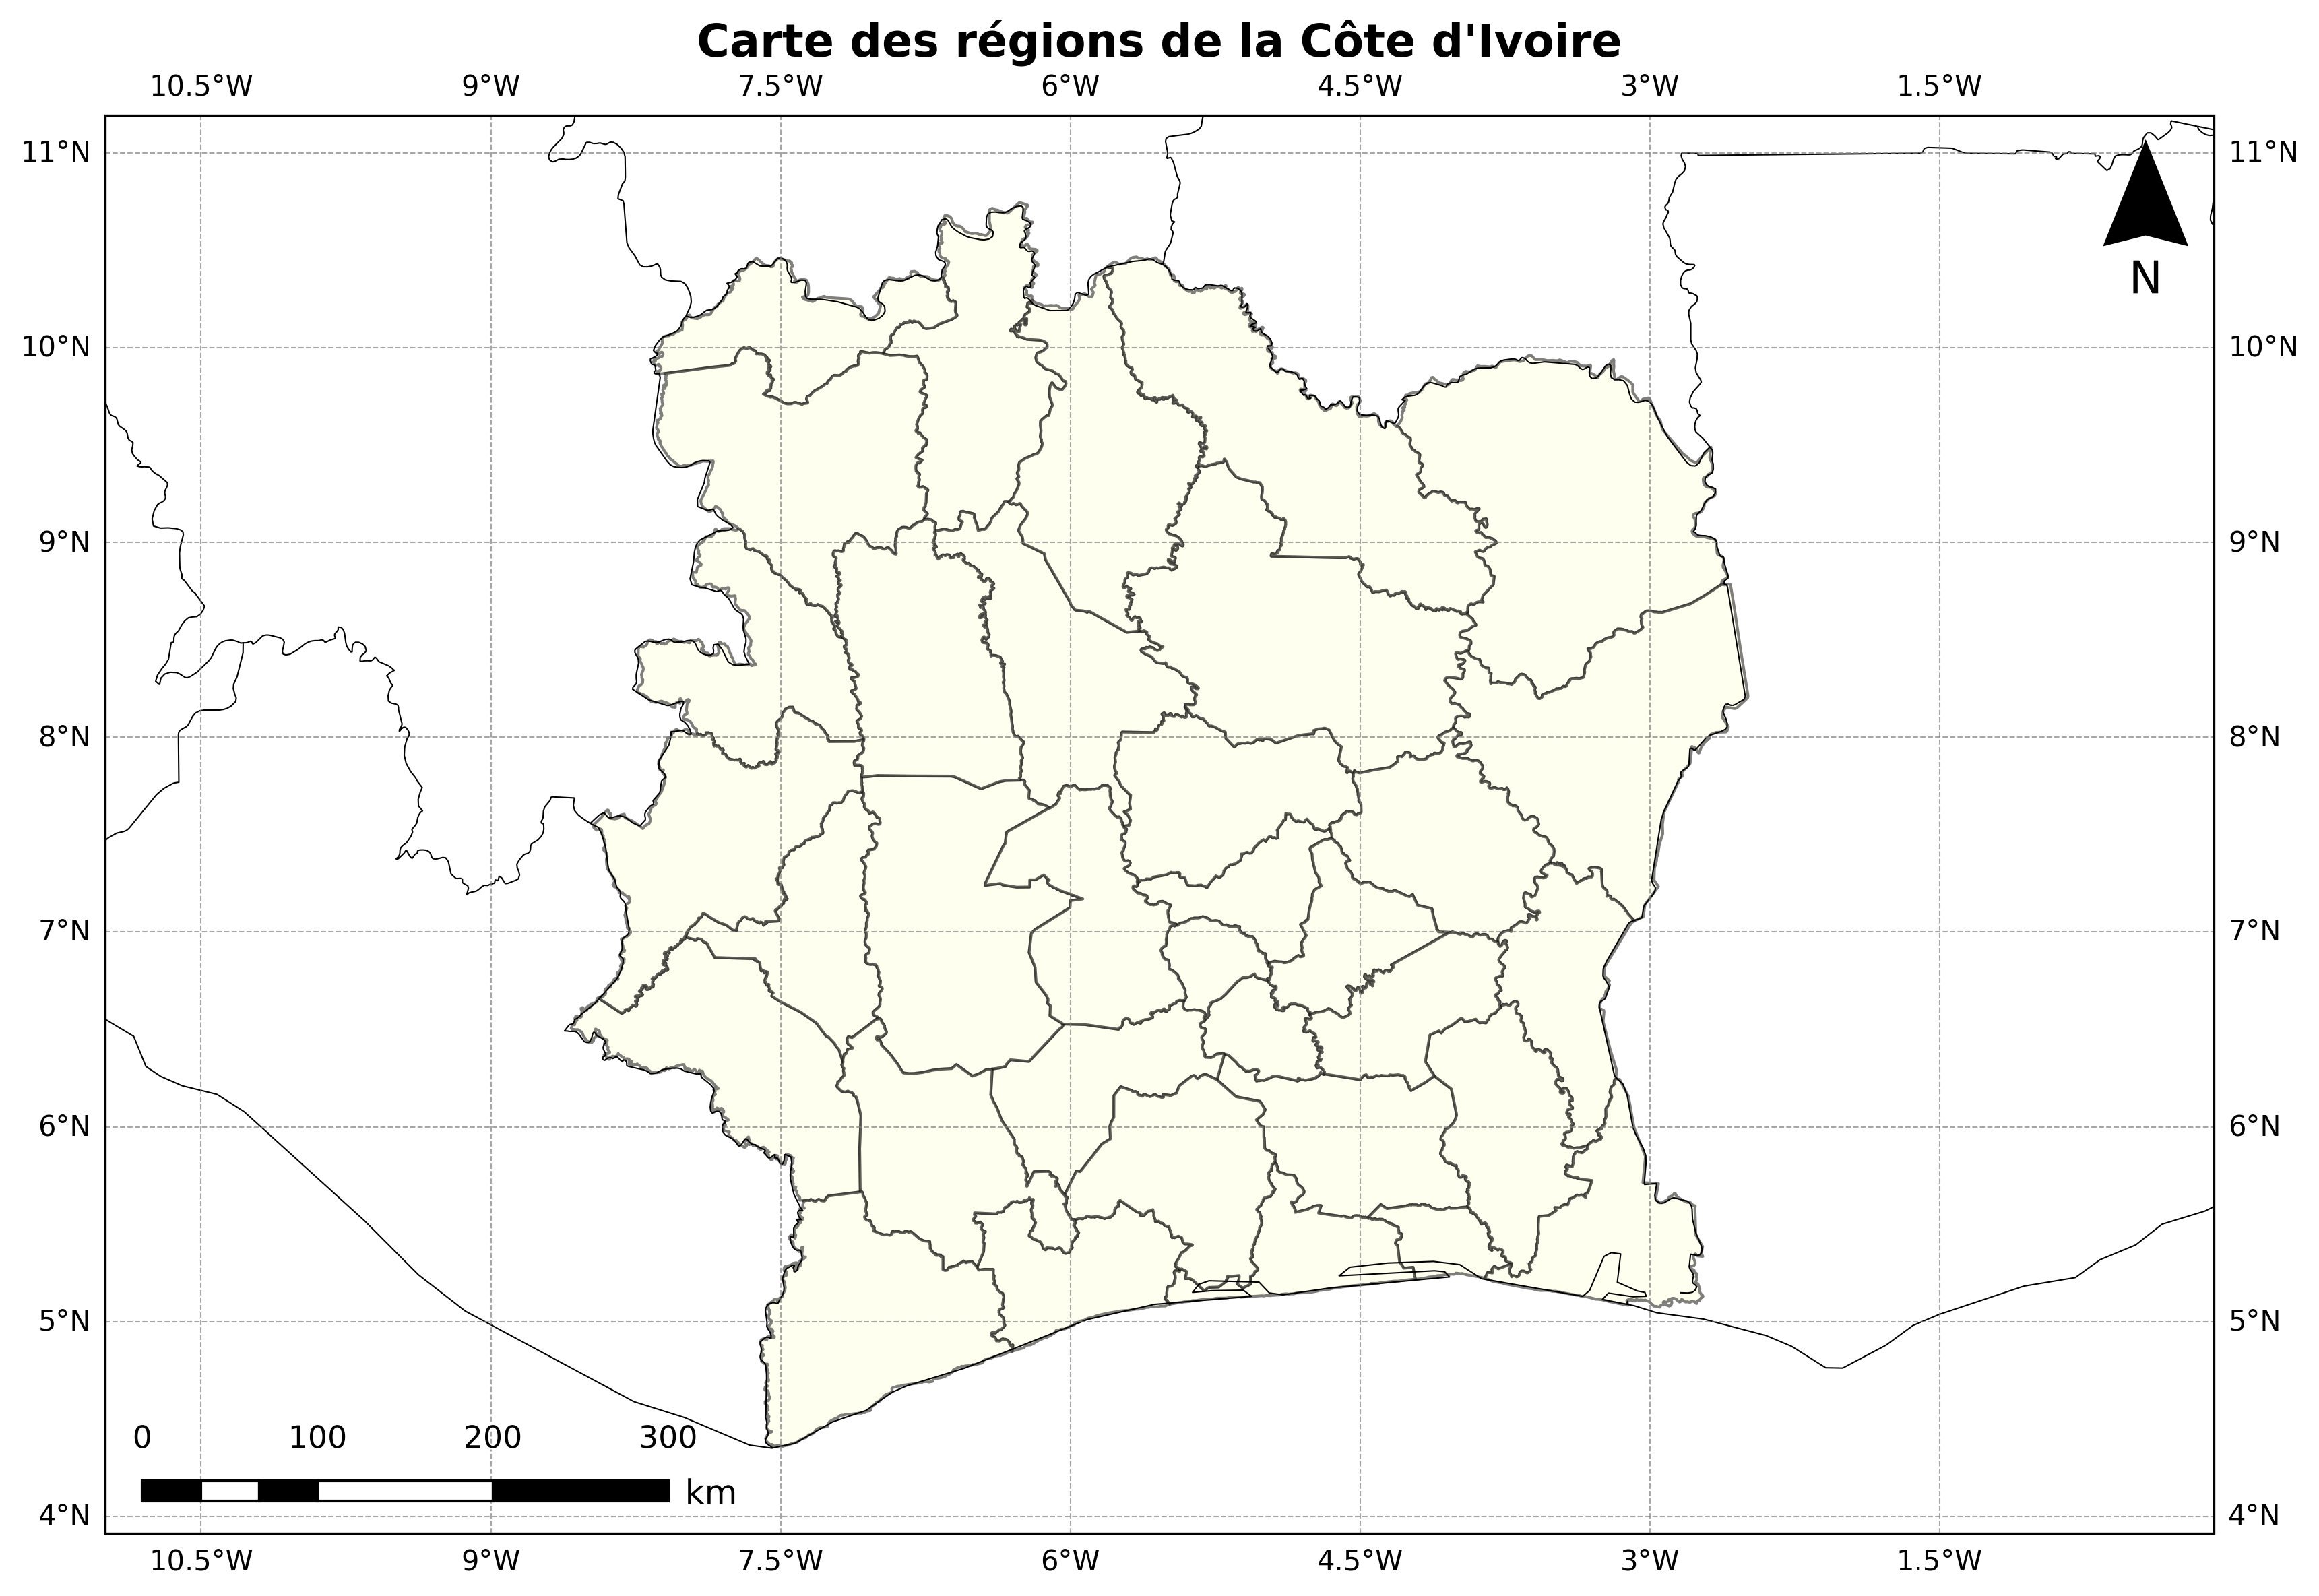

In [1]:
from cartograpy.data import Bound
from cartograpy.mapper import Map

bound = Bound()
civ = bound.get_admin("CIV", adm=2)  # frontières nationales, via GeoBoundaries

m = Map(title="Carte des régions de la Côte d'Ivoire")
m.add_polygons(civ, facecolor="lightyellow", edgecolor="black")
m.add_north_arrow()
m.add_gridlines()
m.add_scale_bar()
m.show()
# m.save("carte_regions_cote_d_ivoire.png", dpi=300)

In [2]:
import cartograpy as cp


geocoder = cp.Geocoder()



C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


AttributeError: module 'cartograpy' has no attribute 'Geocoder'